In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /tmp/cats_and_dogs_filtered.zip

--2022-12-20 07:38:50--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.16.128, 172.217.164.176, 172.217.1.208, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.16.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M   179MB/s    in 0.4s    

2022-12-20 07:38:50 (179 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [30]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import Model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
local_zip = '/tmp/cats_and_dogs_filtered.zip'
zipref = zipfile.ZipFile(local_zip, 'r')
zipref.extractall('/tmp')

In [4]:
base_dir = '/tmp/cats_and_dogs_filtered'
os.listdir(base_dir)

['validation', 'vectorize.py', 'train']

In [5]:
train_dir = '/tmp/cats_and_dogs_filtered/train'
validation_dir = '/tmp/cats_and_dogs_filtered/validation'

print(os.listdir(train_dir))
print(os.listdir(validation_dir))

['cats', 'dogs']
['cats', 'dogs']


In [6]:
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

In [7]:
print('Number of cat images for training   : ', len(os.listdir(train_cats_dir)))
print('Number of dog images for training   : ', len(os.listdir(train_dogs_dir)))
print('Number of cat images for validation : ', len(os.listdir(validation_cats_dir)))
print('Number of dog images for validation : ', len(os.listdir(validation_dogs_dir)))

Number of cat images for training   :  1000
Number of dog images for training   :  1000
Number of cat images for validation :  500
Number of dog images for validation :  500


In [8]:
print(os.listdir(train_cats_dir)[:5])
print(os.listdir(train_dogs_dir)[:5])

['cat.107.jpg', 'cat.991.jpg', 'cat.819.jpg', 'cat.269.jpg', 'cat.3.jpg']
['dog.861.jpg', 'dog.161.jpg', 'dog.578.jpg', 'dog.189.jpg', 'dog.636.jpg']


(-0.5, 499.5, 373.5, -0.5)

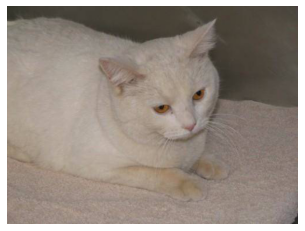

In [9]:
cat_image_path = os.path.join(train_cats_dir, 'cat.486.jpg')
cat_image = mpimg.imread(cat_image_path)
plt.imshow(cat_image)
plt.axis('off')

(-0.5, 498.5, 331.5, -0.5)

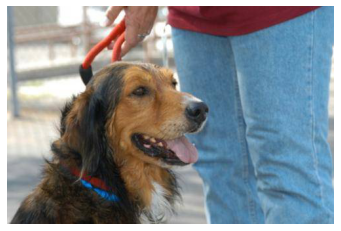

In [10]:
dog_image_path = os.path.join(train_dogs_dir, 'dog.707.jpg')
dog_image = mpimg.imread(dog_image_path)
plt.imshow(dog_image)
plt.axis('off')

In [11]:
print(cat_image_path)
print(dog_image_path)

/tmp/cats_and_dogs_filtered/train/cats/cat.486.jpg
/tmp/cats_and_dogs_filtered/train/dogs/dog.707.jpg


In [12]:
train_cat_images = os.listdir(train_cats_dir)[:50]
train_dog_images = os.listdir(train_dogs_dir)[:50]

print(train_cat_images)
print(train_dog_images)

['cat.107.jpg', 'cat.991.jpg', 'cat.819.jpg', 'cat.269.jpg', 'cat.3.jpg', 'cat.45.jpg', 'cat.146.jpg', 'cat.386.jpg', 'cat.948.jpg', 'cat.872.jpg', 'cat.578.jpg', 'cat.567.jpg', 'cat.508.jpg', 'cat.320.jpg', 'cat.949.jpg', 'cat.169.jpg', 'cat.990.jpg', 'cat.569.jpg', 'cat.186.jpg', 'cat.404.jpg', 'cat.940.jpg', 'cat.634.jpg', 'cat.457.jpg', 'cat.475.jpg', 'cat.759.jpg', 'cat.796.jpg', 'cat.11.jpg', 'cat.77.jpg', 'cat.677.jpg', 'cat.86.jpg', 'cat.120.jpg', 'cat.318.jpg', 'cat.703.jpg', 'cat.869.jpg', 'cat.214.jpg', 'cat.316.jpg', 'cat.517.jpg', 'cat.951.jpg', 'cat.716.jpg', 'cat.941.jpg', 'cat.380.jpg', 'cat.825.jpg', 'cat.955.jpg', 'cat.362.jpg', 'cat.892.jpg', 'cat.779.jpg', 'cat.610.jpg', 'cat.697.jpg', 'cat.443.jpg', 'cat.851.jpg']
['dog.861.jpg', 'dog.161.jpg', 'dog.578.jpg', 'dog.189.jpg', 'dog.636.jpg', 'dog.878.jpg', 'dog.172.jpg', 'dog.262.jpg', 'dog.306.jpg', 'dog.14.jpg', 'dog.681.jpg', 'dog.689.jpg', 'dog.352.jpg', 'dog.432.jpg', 'dog.122.jpg', 'dog.627.jpg', 'dog.701.jpg', 

In [13]:
cat_image_paths = []
dog_image_paths = []

for i in range(50):
  cat_image_paths.append(os.path.join(train_cats_dir, train_cat_images[i]))
  dog_image_paths.append(os.path.join(train_dogs_dir, train_dog_images[i]))

print(cat_image_paths[:5])
print(dog_image_paths[:5])

['/tmp/cats_and_dogs_filtered/train/cats/cat.107.jpg', '/tmp/cats_and_dogs_filtered/train/cats/cat.991.jpg', '/tmp/cats_and_dogs_filtered/train/cats/cat.819.jpg', '/tmp/cats_and_dogs_filtered/train/cats/cat.269.jpg', '/tmp/cats_and_dogs_filtered/train/cats/cat.3.jpg']
['/tmp/cats_and_dogs_filtered/train/dogs/dog.861.jpg', '/tmp/cats_and_dogs_filtered/train/dogs/dog.161.jpg', '/tmp/cats_and_dogs_filtered/train/dogs/dog.578.jpg', '/tmp/cats_and_dogs_filtered/train/dogs/dog.189.jpg', '/tmp/cats_and_dogs_filtered/train/dogs/dog.636.jpg']


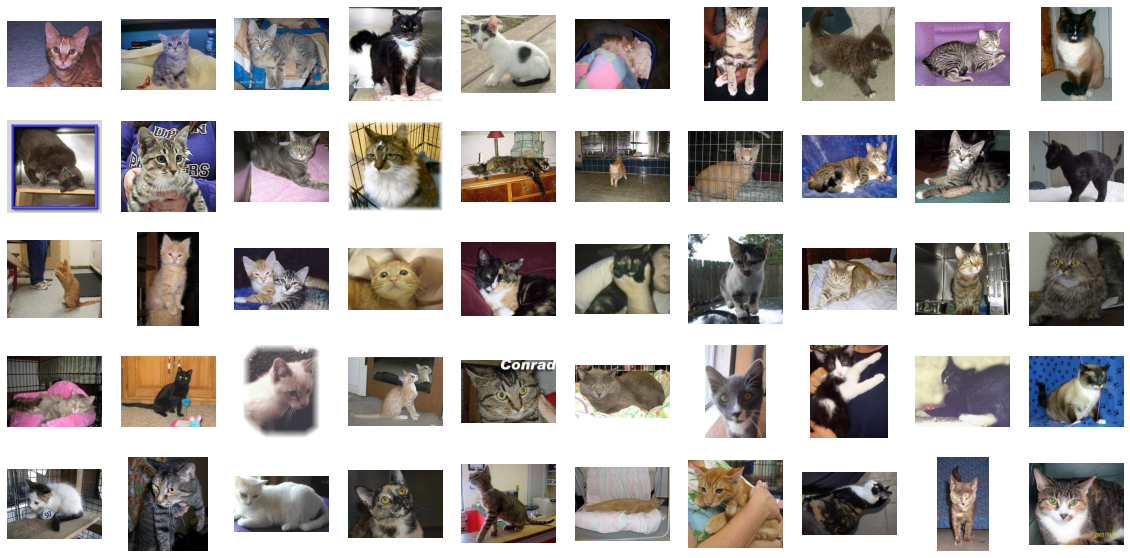

In [14]:
plt.figure(figsize = (20,10))
for i in range(50):
  plt.subplot(5,10, i + 1)
  plt.axis('off')
  cat_image = mpimg.imread(cat_image_paths[i])
  plt.imshow(cat_image)

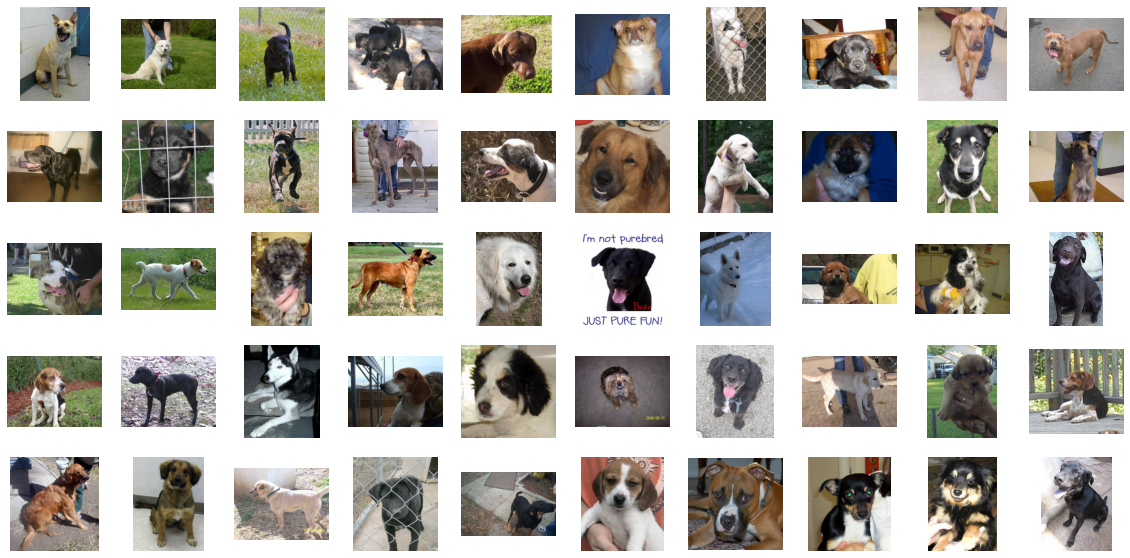

In [15]:
plt.figure(figsize = (20,10))
for i in range(50):
  plt.subplot(5,10, i + 1)
  plt.axis('off')
  dog_image = mpimg.imread(dog_image_paths[i])
  plt.imshow(dog_image)

#-----------------------------------------------------------------------------------------------------------------

In [16]:
train_datagen = ImageDataGenerator(
    rescale = 1 / 255,
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

In [19]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    batch_size = 50,
    target_size = (150,150),
    class_mode = 'binary' 
)

Found 2000 images belonging to 2 classes.


In [20]:
val_datagen = ImageDataGenerator(rescale = 1/255)
val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size = (150,150),
    batch_size = 50,
    class_mode = 'binary'
)

Found 1000 images belonging to 2 classes.


# Using Inception V3

In [21]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5 \
    -O /tmp/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5

--2022-12-20 07:40:50--  https://storage.googleapis.com/mledu-datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.188.208, 172.253.62.128, 172.253.115.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.188.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 87910968 (84M) [application/x-hdf]
Saving to: ‘/tmp/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5’

/tmp/inception_v3_w 100%[===================>]  83.84M   200MB/s    in 0.4s    

2022-12-20 07:40:51 (200 MB/s) - ‘/tmp/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5’ saved [87910968/87910968]



In [23]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

local_weights_file = '/tmp/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

pre_trained_model = InceptionV3(input_shape = (150,150,3),
                                include_top = False,
                                weights = None)

pre_trained_model.load_weights(local_weights_file)

for layer in pre_trained_model.layers:
  layer.trainable = False

pre_trained_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 150, 150, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 74, 74, 32)   864         ['input_2[0][0]']                
                                                                                                  
 batch_normalization_94 (BatchN  (None, 74, 74, 32)  96          ['conv2d_94[0][0]']              
 ormalization)                                                                                    
                                                                                       

In [24]:
last_layer = pre_trained_model.get_layer('mixed7')
print('Last Layer Output Shape : ', last_layer.output_shape)
last_output = last_layer.output

Last Layer Output Shape :  (None, 7, 7, 768)


In [31]:
x = Flatten()(last_output)
x = Dense(1024, activation = 'relu')(x)
x = Dropout(0.2)(x)
x = Dense(1, activation = 'sigmoid')(x)

final_model = Model(pre_trained_model.input, x)

In [32]:
final_model.compile(loss = 'binary_crossentropy',
              optimizer = RMSprop(learning_rate = 0.001),
              metrics = ['accuracy'])

In [33]:
history = final_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 40,
    verbose = 1
)

Epoch 1/40
40/40 [==============================] - 28s 440ms/step - loss: 3.0476 - accuracy: 0.8590 - val_loss: 0.2458 - val_accuracy: 0.9420
Epoch 2/40
40/40 [==============================] - 17s 420ms/step - loss: 0.3110 - accuracy: 0.9245 - val_loss: 0.3770 - val_accuracy: 0.9020
Epoch 3/40
40/40 [==============================] - 17s 418ms/step - loss: 0.2191 - accuracy: 0.9410 - val_loss: 0.1511 - val_accuracy: 0.9600
Epoch 4/40
40/40 [==============================] - 17s 416ms/step - loss: 0.1777 - accuracy: 0.9520 - val_loss: 0.1287 - val_accuracy: 0.9560
Epoch 5/40
40/40 [==============================] - 17s 421ms/step - loss: 0.1185 - accuracy: 0.9620 - val_loss: 0.1581 - val_accuracy: 0.9590
Epoch 6/40
40/40 [==============================] - 17s 419ms/step - loss: 0.1611 - accuracy: 0.9635 - val_loss: 0.3292 - val_accuracy: 0.9290
Epoch 7/40
40/40 [==============================] - 17s 435ms/step - loss: 0.1412 - accuracy: 0.9660 - val_loss: 0.1716 - val_accuracy: 0.9490

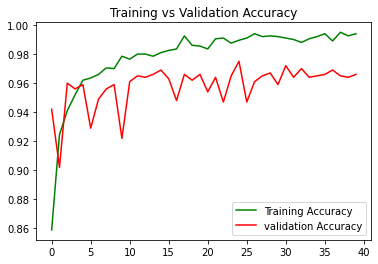

In [34]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure()
plt.plot(train_acc , color = 'green', label = 'Training Accuracy')
plt.plot(val_acc , color = 'red', label = 'validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

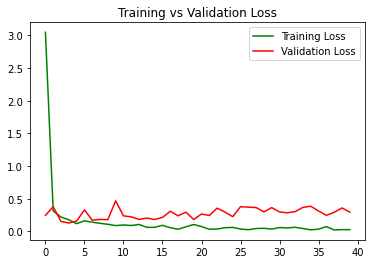

In [35]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(train_loss , color = 'green', label = 'Training Loss')
plt.plot(val_loss , color = 'red', label = 'Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()